# Normalizing EOS records measured on different pressure scales

This notebook puts sample equations of state with Au-, Pt-, and ruby-based pressure provenance onto one named target standard. It demonstrates route discovery, same-marker conversion, optical-scale conversion, complete sample-EOS normalization, and the temperature transformation on the Chidester KCl–Pt bridge.

The transformations create a **derived pressure scale** from published EOS records. They are not observation-level re-reductions unless the original paired sample and calibrant measurements are available.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from peritheos import (
    Material,
    find_common_pressure_calibration_routes,
    get_eos_record_document,
    get_material_document,
    recalculate_eos_pressure_scale,
    recalculate_pressure_calibration_path,
    recalculate_ruby_pressure,
    recalculate_xrd_pressure_scale,
)

plt.style.use("seaborn-v0_8-whitegrid")

## Three sample EOS records with different provenance

The examples mirror a common comparison problem: forsterite used the Fei Au standard, Ca-perovskite used the Holmes Pt standard, and tungsten used the Dewaele ruby scale. The audit metadata identifies these starting nodes; we do not infer them from the material formula or publication year.

In [2]:
source_records = [
    "forsterite_finkelstein_2014_bm3_1",
    "ca_perovskite_shim_2000_bm3_1",
    "tungsten_dewaele_2004_vinet_2",
]

for record_id in source_records:
    audit = get_eos_record_document(record_id)["pressure_calibration"]
    references = [
        method.get("reference_eos_record") or method.get("reference_calibration_record")
        for method in audit["methods"]
    ]
    print(f"{record_id}: {references}")

forsterite_finkelstein_2014_bm3_1: ['gold_fei_2007_vinet_2']
ca_perovskite_shim_2000_bm3_1: ['platinum_holmes_1989_vinet_1']
tungsten_dewaele_2004_vinet_2: ['ruby_dewaele_2004']


## Discover common normalization targets

`find_common_pressure_calibration_routes` tests XRD-standard endpoints and retains those reachable from **every** source. Results minimize the longest route first and total edge count second. This ranking measures graph complexity only: it does not decide which pressure scale has the best accuracy, temperature range, or uncertainty for an experiment.

In [3]:
candidates = find_common_pressure_calibration_routes(source_records)

for candidate in candidates[:5]:
    print(
        candidate.target_node,
        f"(longest={candidate.maximum_path_length}, total={candidate.total_edge_count})",
    )

gold_sokolova_2013_holzapfel_4 (longest=3, total=8)
gold_dewaele_2004_vinet_5 (longest=4, total=8)
gold_fei_2007_vinet_2 (longest=4, total=8)
gold_anderson_1989_bm3_1 (longest=4, total=9)
gold_fratanduono_2021_vinet_7 (longest=4, total=9)


In a real analysis, choose the acceptable family from the science first. Here we explicitly request the Sokolova Au endpoint and inspect every route. Restricting `target_nodes` prevents a short but unwanted standard from becoming the default.

In [4]:
target_record = "gold_sokolova_2013_holzapfel_4"
common = find_common_pressure_calibration_routes(
    source_records, target_nodes=[target_record]
)[0]

for source, path in common.paths.items():
    nodes = [source, *(edge["target_node"] for edge in path)]
    print(" -> ".join(nodes))
    print("  edges:", [edge["identifier"] for edge in path])

forsterite_finkelstein_2014_bm3_1 -> gold_fei_2007_vinet_2 -> gold_sokolova_2013_holzapfel_4
  edges: ['ancestry__forsterite_finkelstein_2014_bm3_1__0', 'same_marker__gold_fei_2007_vinet_2__gold_sokolova_2013_holzapfel_4']
ca_perovskite_shim_2000_bm3_1 -> platinum_holmes_1989_vinet_1 -> platinum_sokolova_2013_holzapfel_3 -> gold_sokolova_2013_holzapfel_4
  edges: ['ancestry__ca_perovskite_shim_2000_bm3_1__0', 'same_marker__platinum_holmes_1989_vinet_1__platinum_sokolova_2013_holzapfel_3', 'sokolova_2013_gold_platinum_family']
tungsten_dewaele_2004_vinet_2 -> ruby_dewaele_2004 -> gold_dewaele_2004_vinet_5 -> gold_sokolova_2013_holzapfel_4
  edges: ['ancestry__tungsten_dewaele_2004_vinet_2__0', 'ancestry__gold_dewaele_2004_vinet_5__0', 'same_marker__gold_dewaele_2004_vinet_5__gold_sokolova_2013_holzapfel_4']


## Two direct building blocks

A same-marker XRD conversion inverts the source Au EOS to a **virtual Au unit-cell volume**, then evaluates the target Au EOS at that coordinate. This volume is calculated—not a measured Au volume from the sample experiment.

In [5]:
xrd = recalculate_xrd_pressure_scale(
    source_pressure_gpa=[20.0, 50.0, 100.0],
    source_standard_eos_record="gold_dewaele_2004_vinet_5",
    target_standard_eos_record="gold_fei_2007_vinet_2",
)
print("virtual Au volumes:", xrd.implied_standard_volume)
print("Fei-scale pressures:", xrd.target_pressure_gpa)

virtual Au volumes: [61.92408392 56.79291685 51.66866304]
Fei-scale pressures: [ 20.00817848  50.01249949 100.01903267]


Ruby-to-ruby conversion instead uses the corrected R1 wavelength ratio as the shared coordinate. This can transform reported pressure values without the original wavelength, but it cannot recover temperature corrections, deviatoric stress, peak-fitting choices, or pressure gradients that were not reported.

In [6]:
ruby_pressure = recalculate_ruby_pressure(
    [20.0, 50.0, 100.0],
    "ruby_mao_1986",
    "ruby_dorogokupets_oganov_2007",
)
print(ruby_pressure)

[ 20.19838284  51.69600748 106.11626327]


## Normalize complete sample EOS curves

`recalculate_eos_pressure_scale` starts from sample volume, evaluates the published sample EOS, reads its calibration audit, and executes the graph route. For a compact reproducible example, we create sample volumes corresponding to 20, 30, and 40 GPa on each published EOS. With experimental data, pass the measured sample volumes instead.

In [7]:
record_locations = {
    "forsterite_finkelstein_2014_bm3_1": "forsterite",
    "ca_perovskite_shim_2000_bm3_1": "ca_perovskite",
    "tungsten_dewaele_2004_vinet_2": "tungsten",
}
published_pressure = np.array([20.0, 30.0, 40.0])
normalized_results = {}

for record_id, material_id in record_locations.items():
    material = Material.from_eosmat(
        get_material_document(material_id), record_identifiers=[record_id]
    )
    eos = material.get_eos_record(record_id)
    sample_volume = eos.volume(published_pressure, eos.reference_temperature)
    inside = eos.within_calibration_range(sample_volume, eos.reference_temperature)
    result = recalculate_eos_pressure_scale(
        source_eos_record=record_id,
        sample_volume=sample_volume,
        target_standard_eos_record=target_record,
        sample_temperature_k=eos.reference_temperature,
        standard_temperature_k=300.0,
        check_validity=True,
    )
    normalized_results[record_id] = result
    print(f"{record_id}: coverage={inside}")
    print("  target pressure:", np.round(result.target_pressure_gpa, 4))

forsterite_finkelstein_2014_bm3_1: coverage=[ True  True  True]
  target pressure: [19.9433 29.8904 39.8383]


ca_perovskite_shim_2000_bm3_1: coverage=[ True  True  True]
  target pressure: [20.31   30.347  40.3175]


tungsten_dewaele_2004_vinet_2: coverage=[ True  True  True]
  target pressure: [19.9515 29.9    39.8494]


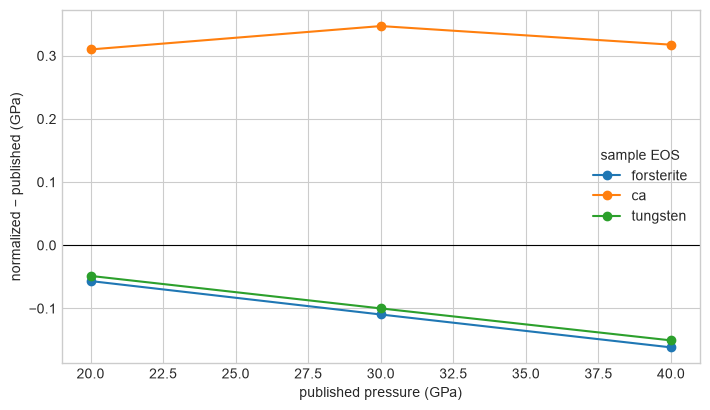

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for record_id, result in normalized_results.items():
    ax.plot(
        published_pressure,
        np.asarray(result.target_pressure_gpa) - published_pressure,
        marker="o",
        label=record_id.split("_")[0],
    )
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set(xlabel="published pressure (GPa)", ylabel="normalized − published (GPa)")
ax.legend(title="sample EOS")
fig.tight_layout()

Every result carries the exact nodes, edge identifiers, and intermediate states. Preserve these with derived data; a target pressure without its route is not auditable.

In [9]:
example = normalized_results["tungsten_dewaele_2004_vinet_2"]
print("path:", example.calibration_path)
for state in example.intermediate_states:
    print(
        state["transformation"],
        state["source_node"],
        "->",
        state["target_node"],
    )

path: ('tungsten_dewaele_2004_vinet_2', 'ruby_dewaele_2004', 'gold_dewaele_2004_vinet_5', 'gold_sokolova_2013_holzapfel_4')
pressure_identity tungsten_dewaele_2004_vinet_2 -> ruby_dewaele_2004
pressure_identity ruby_dewaele_2004 -> gold_dewaele_2004_vinet_5
same_marker_volume gold_dewaele_2004_vinet_5 -> gold_sokolova_2013_holzapfel_4


## A thermal KCl–Pt route

Chidester's B2-KCl record describes KCl used as the pressure medium/thermal insulator and pressure marker. Its fitted KCl temperature is lower than the sample/foil temperature. The explicit KCl–Pt edge therefore transforms temperature as well as carrying pressure to the Dorogokupets–Oganov Pt node. This special temperature mapping is evidence attached to that experiment; it is not a generic KCl rule.

In [10]:
kcl_to_pt = recalculate_pressure_calibration_path(
    source_pressure_gpa=100.0,
    source_node="kcl_b2_chidester_2021_bm3_5",
    target_node="platinum_dorogokupets_oganov_2007_vinet_4",
    temperature_k=1500.0,  # effective KCl temperature
)
state = kcl_to_pt.intermediate_states[0]
print("KCl temperature (K):", state["source_temperature_k"])
print("Pt-foil temperature (K):", state["target_temperature_k"])

KCl temperature (K): 1500.0
Pt-foil temperature (K): 1844.6166666666663


## Before fitting a normalized EOS

1. Choose the target scale/family scientifically; do not select it only because it is the first graph result.
2. Inspect every route and reject edges whose pressure, temperature, phase, or stress assumptions do not match the experiment.
3. Restrict all normalized curves to their common calibration/data envelope.
4. Carry source-EOS and calibration uncertainty. The deterministic helpers do not invent missing covariance.
5. Store the source record, target record, edge identifiers, software version, and whether virtual or measured calibrant volumes were used.